# Axonal Damage Analysis - Step by Step Notebook

This notebook demonstrates the image analysis pipeline for quantifying axonal bead formation as a readout of neurite damage.

**Biological background**: human iPSC-derived neurons exposed to glutamate excitotoxicity (1 mM, 24 h) develop sphere-like structures along neurofilament-positive (SMI-31+) filaments, which are known as axonal beads. Following immunocytochemical staining, these swellings are characterised by high neurofilament intensity and can be used as a quantitative marker of axonal damage in drug screening experiments.

**Publication**: Guerrero Gonzalez, E., et al., (2025). *Development of a Human Preclinical Platform for the Identification of Neuroprotective Compounds*. European Journal of Neuroscience, 62(10), e70328. [https://doi.org/10.1111/ejn.70328](https://doi.org/10.1111/ejn.70328)

**Note**: This notebook mirrors the production pipeline in `src/pipeline.py and src/run_analysis.py`. Use this notebook for development, parameter tuning, and figure generation. Once all parameters are optimized, use the CLI for batch processing.

## 1. Setup and Imports

Import required libraries for image I/O, processing, and visualization.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import filters, measure, util
from scipy import ndimage
import czifile

# Configure matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 2. User-Adjustable Parameters

Modify these parameters in the code to match your experimental conditions. All other cells will use the values specified here.

| Parameter | Default | Description |
|-----------|---------|-------------|
| `INPUT_FOLDER` | `'../docs/sample_data'` | Folder containing `.czi`files |
| `OUTPUT_FOLDER` | `'../docs/example_output'` | Where results and QC images are saved |
| `SCALE_UM_PER_PX` | `0.3126` | Pixel calibration from microscope metadata |
| `DOG_SIGMA1` | `5` | Larger Gaussian sigma — suppresses noise |
| `DOG_SIGMA2` | `1` | Smaller Gaussian sigma — preserves filaments |
| `BEAD_THRESHOLD` | `220` | Manual 8-bit threshold for bead detection (pre-test on representative image!) |
| `BEAD_MIN_SIZE` | `25` | Minimum bead area in pixels |
| `BEAD_MAX_SIZE` | `200` | Maximum bead area in pixels |
| `BEAD_MIN_CIRCULARITY` | `0.3` | Minimum roundness (0 = line, 1 = perfect circle) |
| `SAVE_QC_IMAGES` | `True` | Save neurite masks and bead overlays for quality control |


In [ ]:
# --- USER PARAMETERS ---
INPUT_FOLDER = '../docs/sample_data'
OUTPUT_FOLDER = '../docs/example_output'
SCALE_UM_PER_PX = 0.3126

# Neurite area parameters
DOG_SIGMA1 = 5
DOG_SIGMA2 = 1

# Bead detection parameters
BEAD_THRESHOLD = 220  # MUST be pre-tested on a representative image!
BEAD_MIN_SIZE = 25
BEAD_MAX_SIZE = 200
BEAD_MIN_CIRCULARITY = 0.3

# Output options
SAVE_QC_IMAGES = True

# Verify paths exist
assert os.path.exists(INPUT_FOLDER), f"Input folder not found: {INPUT_FOLDER}"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"Input: {os.path.abspath(INPUT_FOLDER)}")
print(f"Output: {os.path.abspath(OUTPUT_FOLDER)}")

## 3. Core Functions

These functions replicate the ImageJ macro workflow in Python. Each function matches the production CLI implementation.

### 3.1 Read CZI File

Extracts the green channel (SMI-31, neurofilament) from multi-channel CZI confocal images. Assumes 2-channel acquisition: C1 = DAPI (blue), C2 = SMI-31 (green).
- Parameters: `file_path` (path to .czi file)
- Returns: `green: ndarray` (2D array of green channel / SMI-31)

In [3]:
def read_czi(file_path):
    img = czifile.imread(file_path)
    green = np.squeeze(img)[1] # Channel 1 = green / SMI-31
    return green

### 3.2 Measure Neurite Area

Neurofilament-positive (SMI-31+) neurites form a filamentous network. To measure total neurite area, we enhance filaments using Difference of Gaussians (DoG) and isolate them with automatic thresholding. Later on, this will allow us to normalize the number of beads to the SMI-31+ area.

Method:
1. **Difference of Gaussians (DoG)**: Subtracts a narrow Gaussian (σ=1) from a broad Gaussian (σ=5). This enhances filamentous structures while suppressing uniform background.
2. **Triangle auto-threshold**: Automatically determines the optimal threshold for separating filaments from background based on the intensity histogram
3. **Area measurement**: Counts white pixels in the binary mask and converts to µm² using the pixel calibration.

In [4]:
def measure_neurite_area(green, sigma1=DOG_SIGMA1, sigma2=DOG_SIGMA2, scale_um_per_px=SCALE_UM_PER_PX):
    
    # Convert to float for filtering
    green_float = green.astype(float)

    # Difference of Gaussians (inverted to match ImageJ output)
    gauss1 = ndimage.gaussian_filter(green_float, sigma=sigma1)
    gauss2 = ndimage.gaussian_filter(green_float, sigma=sigma2)
    dog = gauss2 - gauss1 # Inverted so filaments are bright

    # Triangle auto-threshold
    neurite_thresh = filters.threshold_triangle(dog)
    neurite_mask = dog > neurite_thresh

    # Measure area
    area_pixels = np.sum(neurite_mask)
    area_um2 = area_pixels * (scale_um_per_px ** 2)

    return {
        "area_um2": area_um2,
        "area_pixels": area_pixels,
        "neurite_threshold": neurite_thresh,
        "mask": neurite_mask,
        "DoG": dog
    }

### 3.3 Count Axonal Beads

Axonal beads are focal swellings along axons characterised by accumulation of neurofilament and other cytoskelletal proteins, which translate into a high SMI-31 intensity. They appear as bright, round spheres distinct from the linear filament morphology.

Method:
1. **Intensity thresholding**: A manual threshold (pre-tested on representative images) isolates the brightest pixels coresponding to the beads.
2. **Connected component labeling**: Groups adjacent bright pixels into candidate objects.
3. **Shape filtering**: leaves out filamentous fragments and noise by requiring minimum circularity and size constraints.
4. **Normalization**: Bead count is divided by total neurite area and multiplied by 1000 to yield beads per 1000 µm²

In [5]:
def count_beads(green, area_um2, bead_thresh=BEAD_THRESHOLD, min_size=BEAD_MIN_SIZE, max_size=BEAD_MAX_SIZE, min_circularity=BEAD_MIN_CIRCULARITY):
    """
    IMPORTANT: bead_thres must be pre-tested on a representative Image!
    Open Image > Adjust > Threshold in Fiji to find the optimal value that isolates the beads.
    """
    # Manual threshold on 8-bit image
    bead_mask = green > bead_thresh

    # Label connected components
    labeled = measure.label(bead_mask)
    regions = measure.regionprops(labeled)

    bead_count = 0
    for reg in regions:
        
        # Size filter (removes noise and artifacts)
        if reg.area < min_size or reg.area > max_size:
            continue

        # Circularity filter (keep round beads, remove filaments)
        if reg.perimeter > 0:
            circularity = 4 * np.pi * reg.area / (reg.perimeter ** 2)
        else:
            circularity = 0
        if circularity < min_circularity:
            continue

        bead_count += 1

    # Normalization: beads per 1000 µm²
    beads_per_1000um2 = (bead_count / area_um2 * 1000) if area_um2 > 0 else 0

    return{
        "bead_count": bead_count,
        "bead_threshold": bead_thresh,
        "beads_per_1000um2": beads_per_1000um2,
        "bead_mask": bead_mask
    }

### 3.4 Process Single Image

Performs neurite area measurement and bead count for a single CZI file. Optionally saves quality control images for validation.

In [6]:
def process_image(file_path, scale_um_per_px=SCALE_UM_PER_PX, bead_thresh=BEAD_THRESHOLD, save_qc=SAVE_QC_IMAGES, output_dir=OUTPUT_FOLDER):
    print(f"\nProcessing: {os.path.basename(file_path)}")

    # Read image
    green = read_czi(file_path)
    print(f"  Image shape: {green.shape}")

    # Neurite area
    neurite = measure_neurite_area(green, scale_um_per_px=scale_um_per_px)
    print(f"  Neurite area: {neurite['area_um2']:.2f} µm² (threshold: {neurite['neurite_threshold']:.2f})")

    # Bead counting
    beads = count_beads(green, neurite['area_um2'], bead_thresh=bead_thresh)
    print(f"  Bead count: {beads['bead_count']} (threshold: {beads['bead_threshold']:.2f})")
    print(f"  Beads/1000µm²: {beads['beads_per_1000um2']:.4f}")

    # Save QC images
    if save_qc and output_dir:
        os.makedirs(output_dir, exist_ok=True)
        base_name = os.path.splitext(os.path.basename(file_path))[0]

        # Neurite mask
        plt.imsave(f"{output_dir}/NeuriteMask_{base_name}.png", neurite['mask'], cmap='gray')

        # Bead overlay
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(green, cmap='gray')
        ax.imshow(beads['bead_mask'], cmap='Reds', alpha=0.5)
        ax.set_title(f"Beads: {beads['bead_count']}")
        ax.axis('off')
        plt.savefig(f"{output_dir}/BeadOverlay_{base_name}.png", dpi=150, bbox_inches='tight')
        plt.close()
    
    return {
        "filename": os.path.basename(file_path),
        "neurite_area_um2": neurite['area_um2'],
        "bead_count": beads['bead_count'],
        "beads_per_1000um2": beads['beads_per_1000um2'],
        "scale_um_per_pixel": scale_um_per_px,
        "neurite_threshold": neurite['neurite_threshold'],
        "bead_threshold": beads['bead_threshold']
    }

## 4. Batch Processing

Process all CZI files in the input folder and compile results into a summary table.

In [7]:
def process_folder(input_dir=INPUT_FOLDER, output_dir=OUTPUT_FOLDER,
                   scale_um_per_px=SCALE_UM_PER_PX,
                   bead_thresh=BEAD_THRESHOLD, save_qc=SAVE_QC_IMAGES):
    
    czi_files = glob.glob(os.path.join(input_dir, '*.czi'))
    print(f"Found {len(czi_files)} CZI files\n" + "="*50)
    
    results = []
    for file_path in sorted(czi_files):
        result = process_image(file_path,
                               scale_um_per_px=scale_um_per_px,
                               bead_thresh=bead_thresh,
                               save_qc=save_qc,
                               output_dir=output_dir)
        results.append(result)
    
    # Compile results
    df = pd.DataFrame(results)
    
    # Save outputs
    os.makedirs(output_dir, exist_ok=True)
    
    csv_path = os.path.join(output_dir, 'Summary_Results.csv')
    df.to_csv(csv_path, index=False)
    print(f"\nSummary saved (CSV): {csv_path}")
    
    excel_path = os.path.join(output_dir, 'Summary_Results.xlsx')
    df.to_excel(excel_path, index=False, sheet_name='Results')
    print(f"Summary saved (Excel): {excel_path}")
    
    return df

## 5. Run Analysis

Execute the pipeline on all images in the input folder

In [8]:
# Run batch processing
df = process_folder()

print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
print(df.to_string(index=False))

Found 2 CZI files

Processing: Glutamate.czi
  Image shape: (1024, 1024)
  Neurite area: 12940.11 µm² (threshold: 25.65)
  Bead count: 91 (threshold: 220.00)
  Beads/1000µm²: 7.0324

Processing: Untreated.czi
  Image shape: (1024, 1024)
  Neurite area: 14105.21 µm² (threshold: 20.44)
  Bead count: 22 (threshold: 220.00)
  Beads/1000µm²: 1.5597

Summary saved (CSV): ../docs/example_output\Summary_Results.csv
Summary saved (Excel): ../docs/example_output\Summary_Results.xlsx

RESULTS SUMMARY
     filename  neurite_area_um2  bead_count  beads_per_1000um2  scale_um_per_pixel  neurite_threshold  bead_threshold
Glutamate.czi      12940.113637          91           7.032396              0.3126          25.650406             220
Untreated.czi      14105.214412          22           1.559707              0.3126          20.440132             220


## 6. Visualization (Optional)

Generate figure panels showing the analysis workflow for a representative image.

To use: Run this section after processing to create figures for your protocol or publication.

Workflow figure saved: ../docs/example_output\analysis_workflow.png


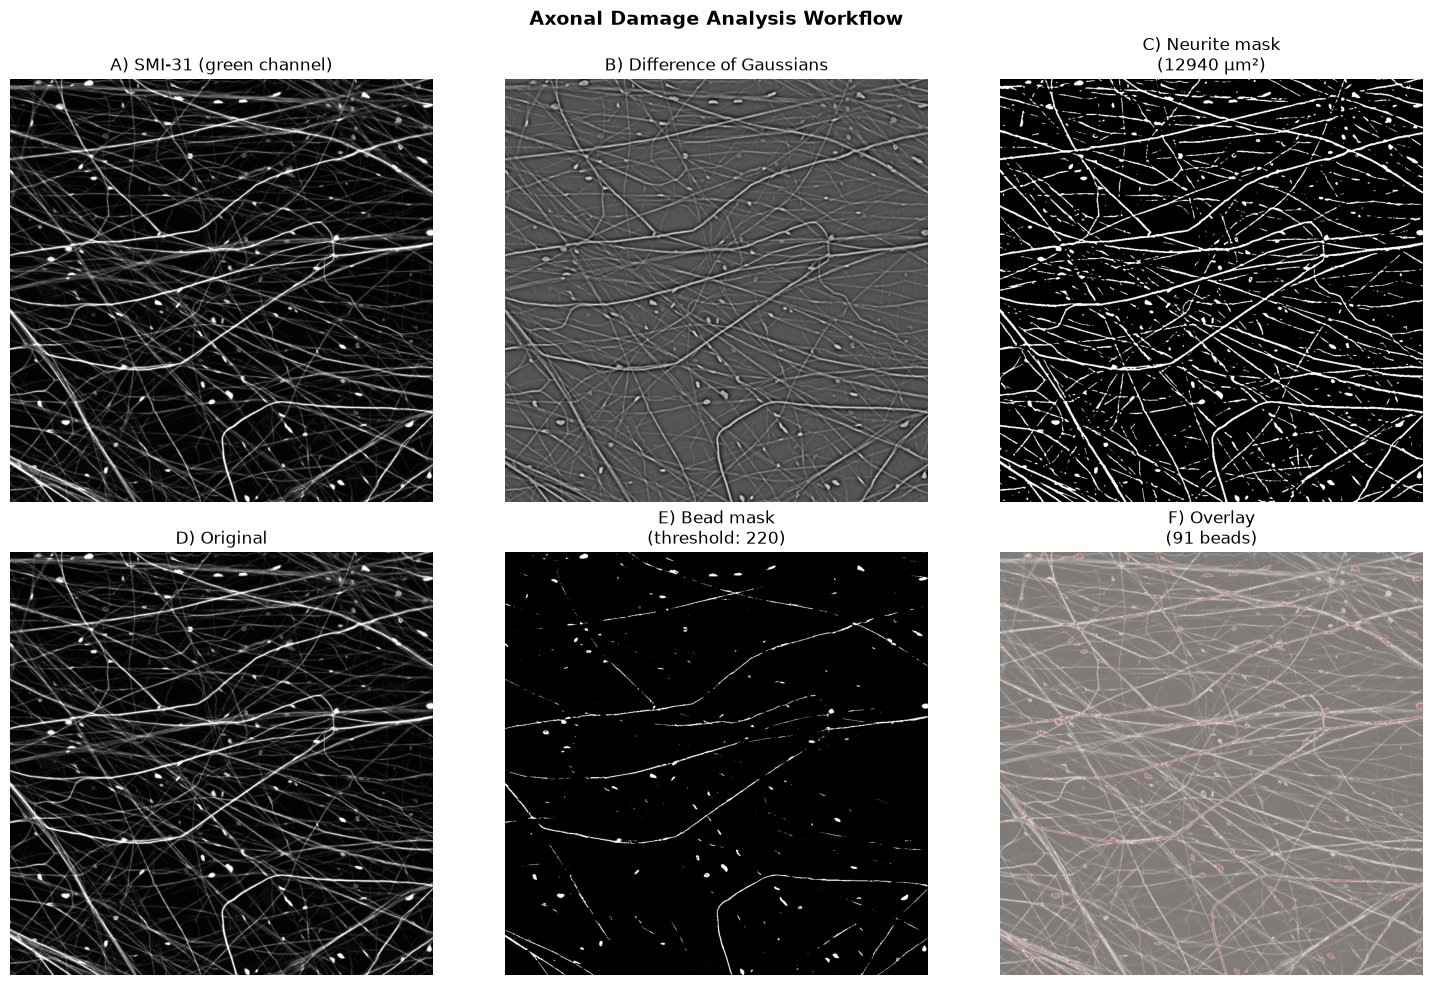

In [9]:
# Select a representative file for figure generation
REPRESENTATIVE_FILE = os.path.join(INPUT_FOLDER, 'Glutamate.czi')  # Update as needed

if os.path.exists(REPRESENTATIVE_FILE):
    green = read_czi(REPRESENTATIVE_FILE)
    neurite = measure_neurite_area(green)
    beads = count_beads(green, neurite['area_um2'])
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Neurite analysis
    axes[0, 0].imshow(green, cmap='gray')
    axes[0, 0].set_title('A) SMI-31 (green channel)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(neurite['DoG'], cmap='gray')
    axes[0, 1].set_title('B) Difference of Gaussians')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(neurite['mask'], cmap='gray')
    axes[0, 2].set_title(f"C) Neurite mask\n({neurite['area_um2']:.0f} µm²)")
    axes[0, 2].axis('off')
    
    # Row 2: Bead analysis
    axes[1, 0].imshow(green, cmap='gray')
    axes[1, 0].set_title('D) Original')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(beads['bead_mask'], cmap='gray')
    axes[1, 1].set_title(f"E) Bead mask\n(threshold: {beads['bead_threshold']:.0f})")
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(green, cmap='gray')
    axes[1, 2].imshow(beads['bead_mask'], cmap='Reds', alpha=0.5)
    axes[1, 2].set_title(f"F) Overlay\n({beads['bead_count']} beads)")
    axes[1, 2].axis('off')
    
    plt.suptitle('Axonal Damage Analysis Workflow', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(OUTPUT_FOLDER, 'analysis_workflow.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Workflow figure saved: {fig_path}")
    plt.show()
else:
    print(f"Representative file not found: {REPRESENTATIVE_FILE}")